In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from factor_analysis import summarize_factors, plot_cumulative
from scipy.stats import skew, kurtosis
from factor_model import *
%matplotlib inline

In [224]:
def get_beta(F, R):
    date_all = sorted(R.index.unique())
    next_date = {date_all[i]: date_all[i + 1] for i in range(len(date_all) - 1)}

    valid_F_dates = [d for d in F.index if d in next_date]
    F_aligned = F.loc[valid_F_dates]
    R_aligned = R.loc[[next_date[d] for d in valid_F_dates]]
    R_aligned.index = F_aligned.index

    beta = np.full((F_aligned.shape[1], R_aligned.shape[1]), np.nan)
    for i in range(R_aligned.shape[1]):
        r = R_aligned.iloc[:, i]
        mask = r.notna()
        beta[:, i] = np.linalg.lstsq(F_aligned.values[mask], r.values[mask], rcond=None)[0]

    R_hat = F_aligned.values @ beta
    resid = R_aligned.values - R_hat
    res_std = np.sqrt(np.nanmean(resid**2, axis=0))
    return beta, res_std, resid, R_hat

def factor_sampler(F):
    F_mean = F.mean()
    F_cov = F.cov()
    sample = np.random.multivariate_normal(F_mean, F_cov)
    return sample

In [225]:
part = 'test'
df1 = pd.read_parquet(f'data/train.parquet')
df2 = pd.read_parquet(f'data/test.parquet')

df = pd.concat([df1, df2], axis=0)
FACTORS = ['growth', 'momentum', 'quality', 'size', 'value', 'volatility']

R = df.pivot_table(index='date', columns='csecid', values='returns')
chars = {f: df.pivot_table(index='date', columns='csecid', values=f) for f in FACTORS}

print(f'Returns:  {R.shape}  ({R.index[0]} → {R.index[-1]})')
print(f'Stocks:   {R.shape[1]}')
print(f'Factors:  {FACTORS}')

Returns:  (3914, 3033)  (2010-12-31 00:00:00 → 2025-12-31 00:00:00)
Stocks:   3033
Factors:  ['growth', 'momentum', 'quality', 'size', 'value', 'volatility']


In [226]:
np.save(f"data/train.npy", R.values)

In [227]:
dates = sorted(R.index.unique())
date      = dates[2]
prev_date = dates[1]
R_t = R.loc[date].sort_index()

B_cols = [chars[f].loc[prev_date].sort_index() for f in FACTORS]
B_df = pd.concat(B_cols, axis=1)

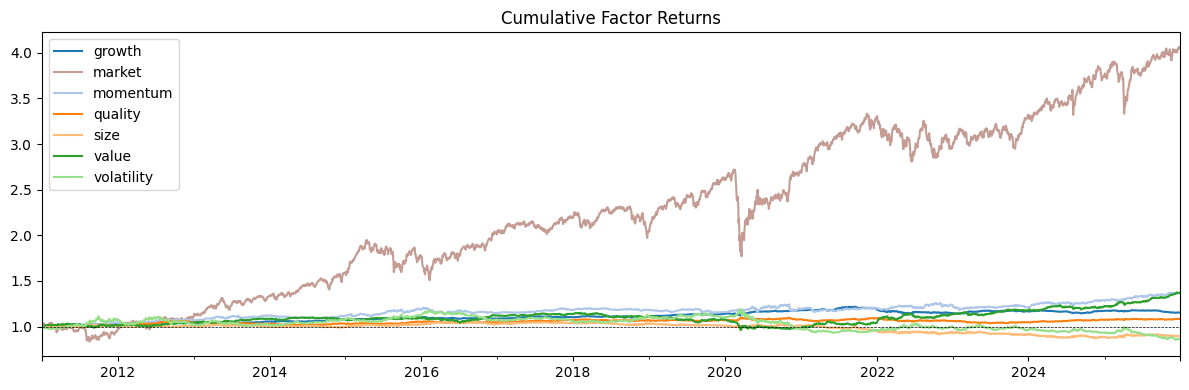

In [228]:
factor_returns = []
valid_dates = []

for i in range(1, len(dates)):
    date      = dates[i]
    prev_date = dates[i - 1]

    R_t = R.loc[date].sort_index()
    B_cols = [chars[f].loc[prev_date].sort_index() for f in FACTORS]
    B_df = pd.concat(B_cols, axis=1)

    mask = R_t.notna() & B_df.notna().all(axis=1)

    R_clean = R_t[mask].values
    B_clean = np.column_stack([np.ones(mask.sum()), B_df[mask].values])


    F_t, _, _, _ = np.linalg.lstsq(B_clean, R_clean, rcond=None)
    eps = R_clean - B_clean @ F_t

    factor_returns.append(F_t)
    valid_dates.append(prev_date)

F = pd.DataFrame(factor_returns, index=valid_dates, columns=['market'] + FACTORS)
regression_summary = summarize_factors(F)

In [229]:
print(regression_summary)

            mean_annual(%)  vol_annual(%)  t_stat  p_value  significant
market                9.81          12.64    3.06   0.0022         True
growth                0.93           1.72    2.14   0.0326         True
momentum              2.09           3.72    2.21   0.0272         True
quality               0.53           1.70    1.22   0.2213        False
size                 -0.61           4.08   -0.58   0.5590        False
value                 2.09           3.36    2.45   0.0142         True
volatility           -0.80           5.35   -0.59   0.5572        False


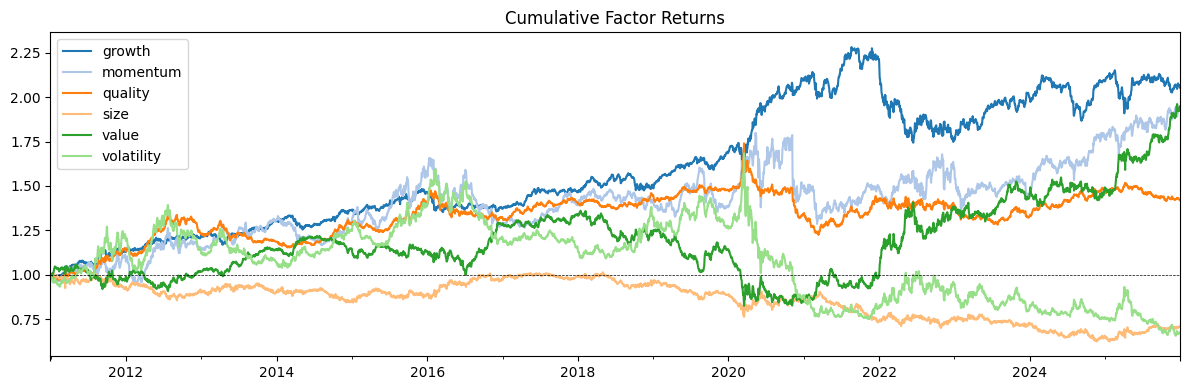

In [230]:
J = 5

dates = sorted(R.index.unique())
all_port_dfs = {}
all_spreads  = {}

for f in FACTORS:
    ports, spreads, valid_dates = [], [], []
    for i in range(1, len(dates)):
        date      = dates[i]
        prev_date = dates[i - 1]
        R_t       = R.loc[date]
        char_prev = chars[f].loc[prev_date]
        mask      = R_t.notna() & char_prev.notna()
        r = R_t[mask]; c = char_prev[mask]
        labels   = pd.qcut(c, q=J, labels=False, duplicates="drop")
        port_ret = r.groupby(labels).mean().reindex(range(J))
        ports.append(port_ret.values)
        spreads.append(port_ret.iloc[-1] - port_ret.iloc[0])
        valid_dates.append(prev_date)
    all_port_dfs[f] = pd.DataFrame(ports, index=valid_dates,
                                   columns=[f"Q{j+1}" for j in range(J)])
    all_spreads[f]  = pd.Series(spreads, index=valid_dates, name=f)


portsort_summary = summarize_factors(pd.DataFrame(all_spreads))


In [231]:
print(portsort_summary.to_string())

            mean_annual(%)  vol_annual(%)  t_stat  p_value  significant
growth                4.96           8.08    2.42   0.0156         True
momentum              5.18          13.80    1.48   0.1390        False
quality               2.49           6.86    1.43   0.1521        False
size                 -1.50          11.92   -0.50   0.6194        False
value                 4.99          11.83    1.66   0.0964        False
volatility           -1.24          15.99   -0.31   0.7591        False


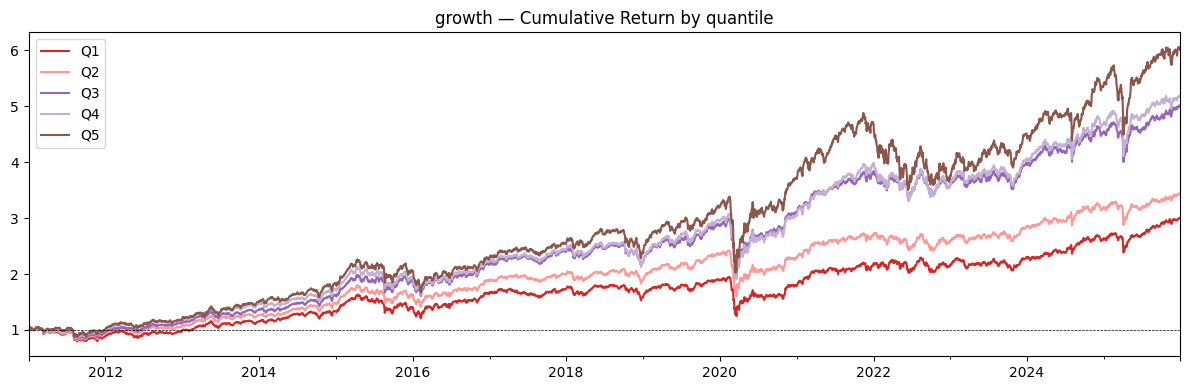

In [232]:
plot_cumulative(all_port_dfs['growth'], title=f"growth — Cumulative Return by quantile")

In [233]:
F_regression = F
F_regression.insert(0, 'alpha', 1.0)
F_portsort = pd.DataFrame(all_spreads)

In [234]:
F_regression.head()

,alpha,market,growth,momentum,quality,size,value,volatility
2010-12-31,1.0,0.008651,0.000986,0.001746,0.000581,-0.001564,-0.000094,-0.004623
2011-01-03,1.0,0.003737,-0.000773,-0.000354,-0.001152,0.001081,0.003356,-0.001194
2011-01-04,1.0,0.006696,0.000392,0.000233,0.001287,-0.002807,-0.001470,-0.003254
2011-01-05,1.0,0.009168,-0.001950,-0.001798,-0.001257,0.001333,0.000047,0.000627
2011-01-06,1.0,0.003448,-0.000669,0.000775,-0.001752,0.000548,-0.000947,0.001503


In [235]:
# save factor returns
F_regression.to_csv(f"data/factor_returns_regression.csv")
F_portsort.to_csv(f"data/factor_returns_portsort.csv")

In [236]:
FF = F_regression
beta_r, res_std, resid, R_hat = get_beta(FF, R)

In [239]:
F_regression_diffusion = np.load("samples/factor_ddpm_2048.npy")

In [240]:
# PSM
N = 2048


In [241]:
def reconstruct_return(fs):
    # step1: draw N factor return samples
    #fs_all = F_regression_diffusion
    # step2: idiosyncratic

    return (fs @ beta_r)  + np.random.normal(0, 1, size=(N, len(res_std))) * res_std[None, :]

In [243]:
# PSM
fs_list = [factor_sampler(FF) for _ in range(N)]
fs_all = np.column_stack(fs_list).T  # (K, N)
PSM_sample = reconstruct_return(fs_all)
np.save("samples/PSM2048.npy", PSM_sample)

In [251]:
fs_all[:, 1:]

array([[-0.00171896, -0.0007738 , -0.00260502, ..., -0.00264395,
        -0.00241959,  0.00229791],
       [-0.00282165,  0.00130807, -0.00111995, ..., -0.00036415,
        -0.00066929, -0.00032127],
       [ 0.01943198,  0.001669  , -0.00106153, ..., -0.00035746,
        -0.00051307, -0.00814281],
       ...,
       [ 0.0010155 , -0.00165527, -0.00154851, ...,  0.0021187 ,
         0.00097906,  0.00173299],
       [ 0.00670769,  0.0010754 , -0.00050833, ..., -0.00143565,
         0.00067455, -0.00567785],
       [ 0.00284323, -0.000979  , -0.00260606, ..., -0.00286424,
        -0.00288816, -0.00340346]], shape=(2048, 7))

In [246]:
# PSM diffusion
fs_ddpm = np.load("samples/factor_ddpm_2048.npy")
fs_ddpm = np.hstack([np.ones((fs_ddpm.shape[0], 1)), fs_ddpm])
PSMDiff_sample = reconstruct_return(fs_ddpm)
np.save("samples/PSMDiff2048.npy", PSMDiff_sample)

In [247]:
fs_ddpm.shape, fs_all.shape

((2048, 8), (2048, 8))

In [101]:
# synthesized
N = FF.shape[0]
fs_resample = FF.values  # (K, N)
PSMResample_sample = reconstruct_return(fs_resample)
np.save("data/PSMExactlys3913.npy", PSMResample_sample)

In [205]:
R_real = R.values
res_mean = np.nanmean(resid, axis=0)
R_gen = (FF.values @ beta_r)  + np.random.normal(0, 1, size=(N, len(res_std))) * res_std[None, :]
np.save("data/PSMExactlys3913.npy", R_gen)

In [258]:
Fb = FF.values @ beta_r
kurt_fb = kurtosis(Fb, axis=0, nan_policy='omit')
kurt_res = kurtosis(resid, axis=0, nan_policy='omit')
kurt_sum = kurtosis(Fb + resid, axis=0, nan_policy='omit')
kurt_sampled = kurtosis(Fb + np.random.normal(0, 1, size=(FF.shape[0], len(res_std))) * res_std[None, :], axis=0, nan_policy='omit')
print(f"Factor part kurtosis std: {np.nanmean(kurt_fb):.2f}")
print(f"Residual kurtosis std: {np.nanmean(kurt_res):.2f}")
print(f"Total return kurtosis std: {np.nanmean(kurt_sum):.2f}")
print(f"Sampled return kurtosis std: {np.nanmean(kurt_sampled):.2f}")

Factor part kurtosis std: 10.33
Residual kurtosis std: 17.41
Total return kurtosis std: 13.22
Sampled return kurtosis std: 1.22


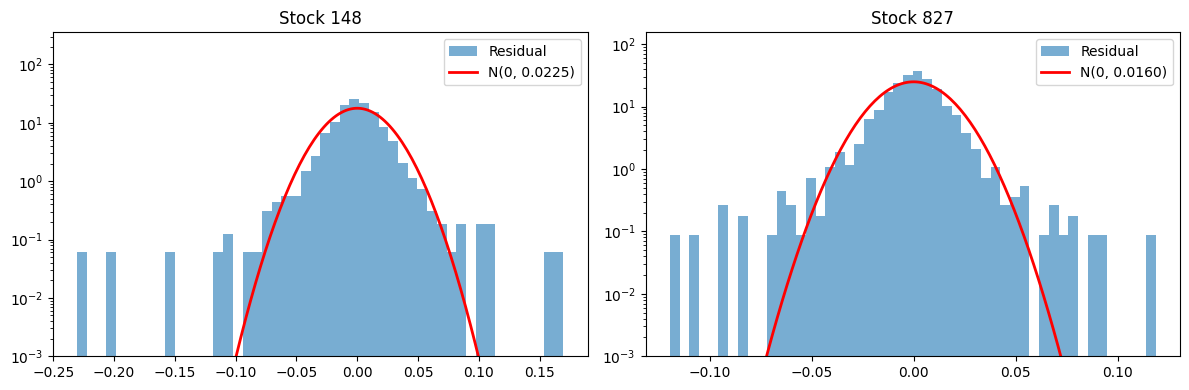

In [181]:
from scipy.stats import norm

s1, s2 = np.random.choice(resid.shape[1], 2, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s in zip(axes, [s1, s2]):
    r = resid[:, s]
    r = r[~np.isnan(r)]
    ax.hist(r, bins=50, density=True, alpha=0.6, label='Residual')

    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, norm.pdf(x, 0, res_std[s]), 'r-', linewidth=2, label=f'N(0, {res_std[s]:.4f})')
    ax.set_yscale('log')
    ax.set_ylim(1e-3, None)
    ax.set_title(f'Stock {s}')
    ax.legend()

plt.tight_layout()

In [183]:
R_real.shape, R_gen.shape
np.save("data/PSMExactlys3913.npy", R_gen)

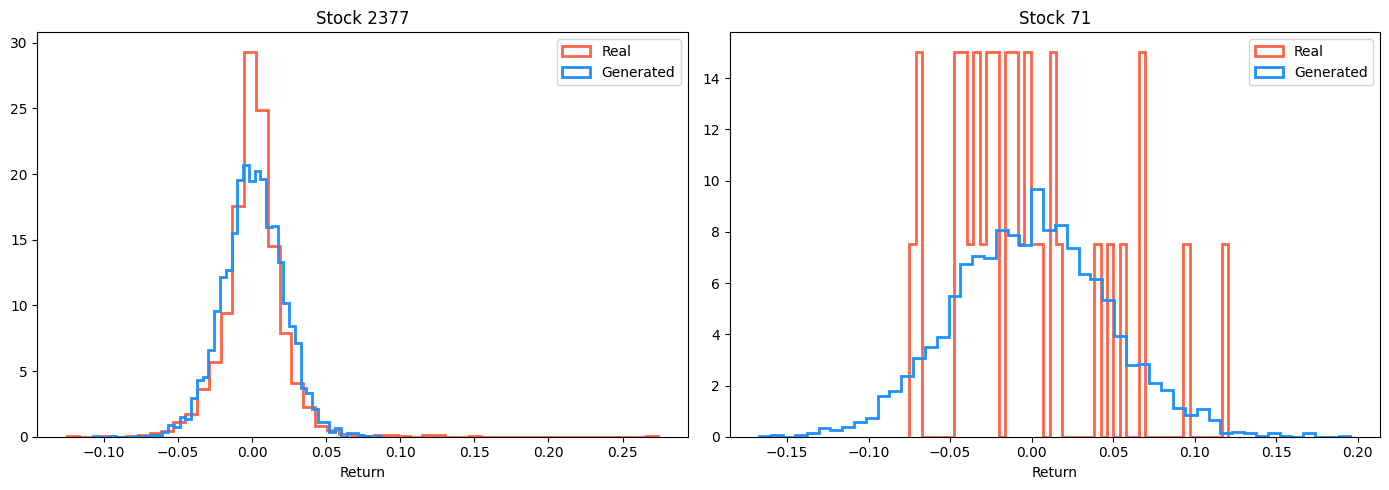

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

s1, s2 = np.random.choice(R_real.shape[1], 2, replace=False)

for ax, s in zip(axes, [s1, s2]):
    real_s = R_real[:, s][~np.isnan(R_real[:, s])]
    gen_s = R_gen[:, s][~np.isnan(R_gen[:, s])]
    #without_res = R_without_res[:, s][~np.isnan(R_without_res[:, s])]

    ax.hist(real_s, bins=50, density=True, label='Real', color='tomato', histtype='step', linewidth=2)
    ax.hist(gen_s, bins=50, density=True, label='Generated', color='dodgerblue', histtype='step', linewidth=2)
    #ax.hist(without_res, bins=50, density=True, label='Without Residual', color='blue', histtype='step', linewidth=2)

    ax.set_title(f'Stock {s}')
    ax.set_xlabel('Return')
    ax.legend()

plt.tight_layout()
plt.show()

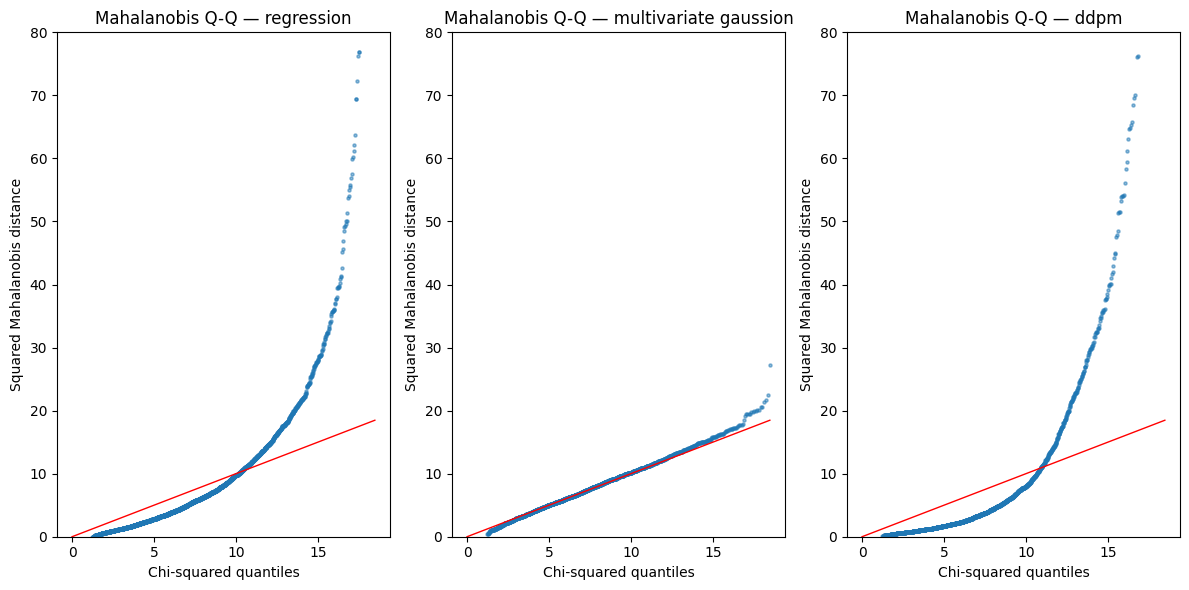

In [253]:
fig, (ax1, ax2, ax4) = plt.subplots(1, 3, figsize=(12, 6))

axs = [(ax1, F_regression.values, "regression"),
                     (ax2, fs_all, "multivariate gaussion"),
       (ax4, fs_ddpm, "ddpm")]
for ax, XX, title in axs:
    X = XX[:, 1:]
    p = X.shape[1]
    mean = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    diff = X - mean
    d2 = (diff @ np.linalg.inv(cov) * diff).sum(axis=1)
    quantiles = stats.chi2.ppf(np.linspace(0.01, 0.99, len(d2)), df=p)
    ax.set_ylim(0, 80)
    ax.scatter(quantiles, np.sort(d2), s=5, alpha=0.5)
    ax.plot([0, quantiles.max()], [0, quantiles.max()], color="red", linewidth=1)
    ax.set_xlabel("Chi-squared quantiles")
    ax.set_ylabel("Squared Mahalanobis distance")
    ax.set_title(f"Mahalanobis Q-Q — {title}")

plt.tight_layout()
plt.show()



In [40]:
# Residual Dynamics
beta_r, res_std, resid, R_hat = get_beta(F_regression, R)

In [41]:
res_sample = np.random.normal(0, 1, size=res_std.shape)

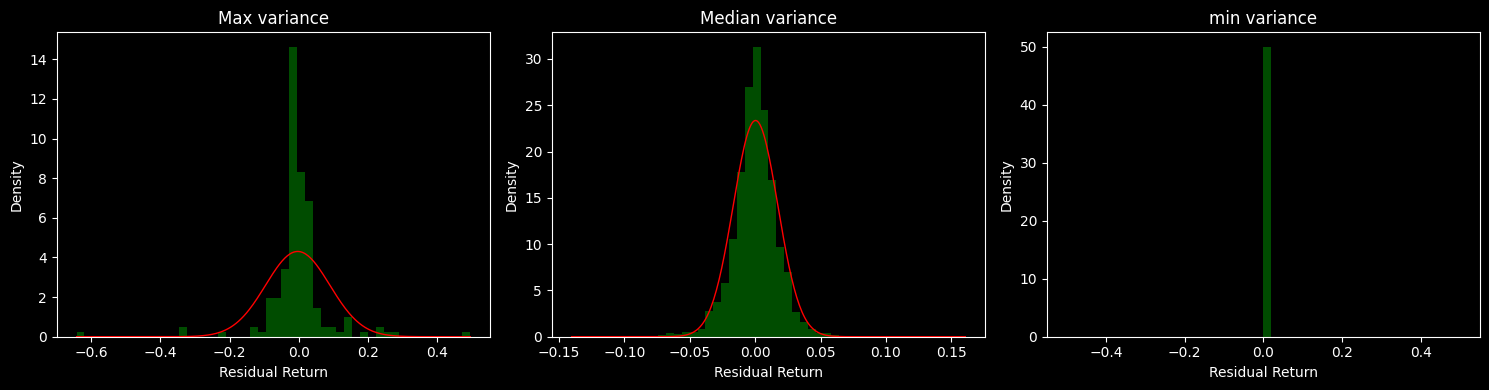

In [42]:
resid_var = np.nanvar(resid, axis=0)
idx_max    = np.nanargmax(resid_var)
idx_median = np.argsort(resid_var)[len(resid_var) // 2]
idx_min   = np.nanargmin(np.abs(resid_var))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx, label in zip(axes,
                         [idx_max, idx_median, idx_min],
                         ['Max variance', 'Median variance', 'min variance']):
  r = resid[:, idx]
  r = r[~np.isnan(r)]
  ax.hist(r, bins=50, density=True, alpha=0.6, color='g')
  x = np.linspace(r.min(), r.max(), 300)
  ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color='red', linewidth=1)
  ax.set_title(label)
  ax.set_xlabel('Residual Return')
  ax.set_ylabel('Density')

plt.tight_layout()
plt.show()